# Getting started with digital logic

Welcome to the Introduction to FPGAs workshop!

* _Who is this workshop for?_ all undergraduate students who want to learn how FPGAs work, and how to make FPGAs work for them.
* _What will you learn?_ What the technology is, the motivations for creating and using the technology, common design practices, and usage examples.
* _How will you learn it?_ You will use interactive code examples below, running on your own laptop, with all dependencies pre-installed.
* _Can I learn more?_ Workshop two is in-person: you'll be able to apply the concepts you learn here to a physical FPGA evaluation board. It is on `PLACEHOLDER_DATE` at `PLACEHOLDER_LOCATION`.

## What is an FPGA?

An FPGA (field-programmable gate array) is a chip you can program to do any task you want by wiring up its internal components in different ways. Think of it as a set amount of blocks, each which may be connected to any other, and which may be reconnected again and again so that the same inputs become different outputs on each reconfiguration. These blocks form a **digital circuit**. Therefore, a FPGA is one way of implementing a digital circuit.

> A digital circuit is a circuit where the inputs and outputs are booleans (only ones and zeroes). When inputs change, we may make the assumption that the outputs will change immediately after (after a very small time). How the outputs change is determined by the "gates" that the inputs pass through. Each gate is represented by a **symbol** in a **circuit diagram**. Certain gates are **fundamental** in that they are easily converted from the logical representation to a physical form (electrical circuit).



The diagram above shows a digital circuit with a single output, named `out` and three inputs `a`, `b`, and `c`. Let's build up our intuition on what each gate does. Well, its symbol tells us:

|Symbol|Name|What it does|
|---|---|---|
||Buffer|The output is equal to the input.|
||AND|The output is one only if **all inputs are 1**, else it is zero.|
||OR|The output is one if **any input is 1**, else it is zero.|
||NOT|The output is the opposite of the input. If the input is one, the output is zero; if the input is zero, the output is one.|
||XOR (exclusive or)|The output is one only if **exactly one input is 1**.|



Tracing our path through this digital circuit: some of the gates are listed above, and therefore we know how their outputs are produced. In fact, one way of giving names to each gate's output is to write the gate name and then the inputs of the gate in brackets. But what does gate three do? Gate three is an OR gate with the same circle in front as gate two, a NOT gate. It outputs the opposite of what an OR gate would output for its inputs. It is called a NOR (Not-OR) gate.


> Now, using the same reasoning approach, what does the below gate do? What is its name?
>
> 

### All digital circuits are tables

How would we figure out what the outputs of this digital circuit are?
One way is with a table of inputs to outputs, called a _truth table_.
Each unique input combination is listed on the left hand side, and the corresponding output is written on the right hand side. How would this look for the output named `out` of the circuit we have been working with?



Well, if `out = XOR(NOR(AND(a, b), NOT(c)), NOT(c))`, the final truth table is:

|a|b|c|`out`|
|---|---|---|---|
|0|0|0|**1**|
|0|0|1|**1**|
|0|1|0|**1**|
|0|1|1|**1**|
|1|0|0|**1**|
|1|0|1|**1**|
|1|1|0|**1**|
|1|1|1|**0**|

Any digital circuit can be fully described by a truth table.

> **Exercise:** How would you create this truth table? How can you check that it is correct?

### Tables can verify digital circuits

_Or: the interface versus the implementation_

What if we already know what every output should be for a digital circuit, for every possible combination of input values? An engineer must implement this specification.

For example, what is another circuit which could generate the truth table we saw earlier? Could we use fewer gates? (less cost).

|a|b|c|`out`|
|---|---|---|---|
|0|0|0|**1**|
|0|0|1|**1**|
|0|1|0|**1**|
|0|1|1|**1**|
|1|0|0|**1**|
|1|0|1|**1**|
|1|1|0|**1**|
|1|1|1|**0**|

To start answering these questions, we can first prepare a **test bench**. A test bench is a program which verifies that a digital circuit is correct, given a specification, by providing to it different inputs and checking that the output matches the truth table of what we want. The digital circuit is called a _design under test_ (DUT), and the test bench provides different input combinations to it to verify its correctness. A useful digital circuit will have thousands of inputs, so a test bench usually does not check every possible input combination. Some techniques to reduce the number of needed input combinations include:

1. Checking that common input combinations named **test vectors** (so named because the set of zeroes and ones that is one input combination can be represented as a single vector) each result in the correct output.
2. Checking "edge cases", particular input combinations which are selected from engineers' gut feeling.
3. Checking random input combinations. The test bench will calculate the expected outputs on the fly and compare them to the digital circuit's output. Since the test bench is written in more expressive language, it is often more easy to specify this calculation than it is in the digital circuit's HDL description!

> A related verification technique is named _formal verification_. In this method, logical assertions on the output of a digital circuit are given along with the description of the circuit (in the same code). The verification tool then tries to find an input vector which is a counterexample to the assertion.

In the next section we will represent the digital circuit we saw earlier with a structured _hardware description language_ (HDL) named Verilog. We will then write a test bench for this Verilog code to make sure it works.

## How does an FPGA work?

An FPGA can be thought of physically as a grid of blocks (which are the gates of the digital circuit) connected by wires. These wires are then connected to each other by a complex network of programmable switches. The switches are programmed by a _bitstream_.

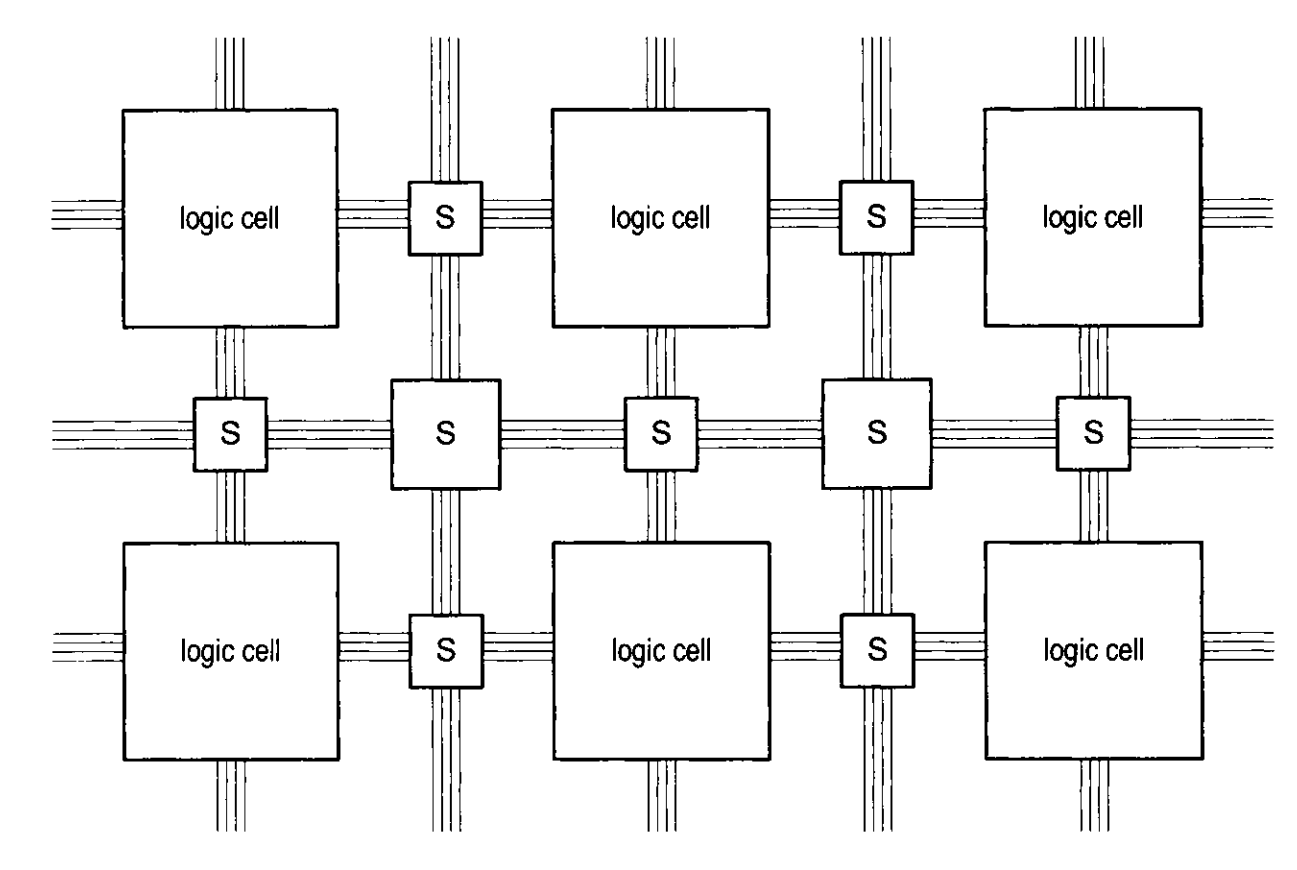

The FPGA is programmed like so: a hardware description language is converted into a netlist (a tree of connected logic gates). The netlist then passes through a place and route (PnR) algorithm, a specialized program provided by the FPGA vendor which understands the location of each block and each programmable switch. The PnR algorithm encodes the state of each switch as either ON or OFF and also encodes the state of each block (what type of digital logic gate it will become) in the same _stream of bits_. This is the bitstream, which is then transmitted to the FPGA chip. The transmission step is done using a serial protocol such as USB (universal serial bus) which is then interpreted by the circuit around the main FPGA chip to program the chip itself; the whole process is specified by the manufacturer.

## Coding using HDL

Let's try to implement the digital circuit, and turn its diagram into concrete Verilog HDL. Along the way, we'll learn Verilog syntax.



Every digital circuit can be thought of as a "black box" exposing only inputs and outputs. Verilog uses the concept of a `module` to represent this black box. A `module` has fixed (static) inputs and outputs which cannot change: after all, we cannot expect to change our circuit on the fly!

```verilog
module digital_example(
    input a,
    input b,
    input c,
    output out
);
    logic gate_1, gate_2, gate_3;
  
    assign gate_1 = a & b;
    assign gate_2 = ~c;
    assign gate_3 = gate_1 ~| gate_2;
    assign out = gate_3 ^ gate_2;

endmodule
```

This code has a lot of new syntax to express what we did!
Let's walk through it.

* First, we declared our inputs and outputs.
* Then, we created our gates. But what is the `logic` keyword doing? Turns out, we are not creating our gates here, but instead we are giving names to the _outputs of each gate_. These outputs have the **type** `logic`, because they are boolean values (and there are more details we will get to!)
* Next, we `assign`ed some operation on `a`, `b`, `c`, and the gates to each gate. Within these lines must be the actual gates. Yes, they are `&` (AND), `~` (NOT), `~|` (NOR), and `^` (XOR).

[TBD: flashing this onto the FPGA? using Quartus]

So what we have done is traced the entire path from input to output in text instead of diagram form.

> **Exercise:** how would you implement the following digital circuit in the Verilog?
>
> 
>
> * Tip 1: The OR gate is `|` in Verilog.
> * Tip 2: Connection points (where two wires are connected) are marked as black, filled-in circles.
>
> What did you implement? (How is the output related to the input?)

## Creating a test bench in Verilog

So, before we used the following Verilog:

```verilog
module digital_example(
    input a,
    input b,
    input c,
    output out
);
    logic gate_1, gate_2, gate_3;
  
    assign gate_1 = a & b;
    assign gate_2 = ~c;
    assign gate_3 = gate_1 ~| gate_2;
    assign out = gate_3 ^ gate_2;

endmodule
```

To implement the digital circuit described in the diagram:



Let's walk through how to simulate this code using a test bench. Verilog has key words specifically meant for simulating circuits. This means that you don't need access to a physical FPGA to check if your circuits are functional. Here is a test bench for the above example:

```verilog
module test_digital_example;
    logic [3:0] test_vector [7:0];
    logic a_test, b_test, c_test, out;
    logic tb_out;

    // This is a comment (because it starts with //)
    digital_example de_inst(
        .a(a_test), // Connect the input a of digital_example to a_test
        .b(b_test),
        .c(c_test),
        .out(out)   // Can be the same name
    );

    initial begin
        // Array syntax is '{ elem1, elem2, elem3 }
        test_vector = '{
            4'b0001,
            4'b0011,
            4'b0101,
            4'b0111,
            4'b1001,
            4'b1011,
            4'b1101,
            4'b1110
        };

        for (int i = 0; i < 8; i++) begin
            {a_test, b_test, c_test, tb_out} = test_vector[i];
            #1; // wait one step on the time scale
            assert (out == tb_out);
        end
        $display("All tests passed!");
        $finish;
    end
endmodule
```

Running this should give you the output:

```bash
$  verilator test_digital_example.sv --binary --timing
$  ./obj_dir/(binary name)

All tests passed!
- test_digital_example.sv:33: Verilog $finish
- S i m u l a t i o n   R e p o r t: Verilator 5.040 2025-08-30
- Verilator: $finish at 8ps; walltime 0.001 s; speed 5.791 ns/s
- Verilator: cpu 0.001 s on 1 threads; alloced 118 MB
```

The key idea is that to test your circut, you wrap it up in a larger circuit with no inputs and no outputs. This larger circuit is the test bench, and it has a preset. Further notice how we simply enumerated the truth table of the digital circuit we wished to build in our testbench.